# Integrate an ArcGIS Feature Service

This notebook integrates a public ArcGIS Feature Service into ARGUS using the new `%%skill-build` cell magic. The user writes no Python — paste the
service URL into a `%%skill-build` cell and ARGUS produces a queryable skill in the same cell.

We integrate the California wildfire perimeters service (CAL FIRE / NIFC / FIRIS), then query it in natural language to confirm it works end-to-end. A
follow-up query joins the new skill against a public-schools skill from GitHub, confirming the freshly-built skill behaves like any other skill in the
agent's toolset.

####   **Choose your language model**
  
  Argus is model-agnostic — you can plug in any of the major LLM providers and Argus will work. Pick whichever you have an API key for. To switch, comment out the active `LLM = {...}` block and uncomment the one you want.

  **This notebook defaults to GLM-5 via the National Research Platform** (free for NRP users, strong on scientific tool use). If you don't have NRP
  access, swap in OpenAI, Anthropic, or Google — they all work.

  **Before you run the cell: save your API key as a Colab Secret**

  Argus reads your API key from a Colab Secret, not from the notebook itself — that keeps the key out of your saved file and out of anyone you share the
  notebook with.

  1. Click the 🔑 key icon in the left sidebar (**Secrets**).
  2. Click **+ Add new secret**.
  3. Set the **Name** to match the `api_key_env` value in your `LLM` block:
     - `NRP_API_KEY` for GLM-5 on NRP
     - `OPENAI_API_KEY` for GPT-5.5
     - `ANTHROPIC_API_KEY` for Claude Sonnet/Opus
     - `GOOGLE_API_KEY` for Gemini

  4. Paste your key into the **Value** field.
  5. Toggle **Notebook access** on for this notebook.

  If the key isn't set (or notebook access is off), Argus will fail with an authentication error when it tries to call the model.

  ### Supported models

  | Provider | Models |
  |---|---|
  | OpenAI | GPT-5.5, GPT-5.4 |
  | Anthropic | Claude Opus 4.7, Opus 4.6 |
  | Google | Gemini 3.5 Flash |
  | Z.ai | GLM-5, GLM-5.1 |
  | Moonshot | Kimi-K2.6 |
  | MiniMax | MiniMax-M2.7 |
  | DeepSeek | DeepSeek-V4 Flash |

  Any model in this list should run Argus notebooks correctly. The four pre-configured blocks below are starter templates; for the others, follow the
  same `LLM = {...}` pattern with the right `model` and `api_key_env`.

In [1]:
# Use GLM-5 from National Research Platform
# LLM = {
#     "model": "glm-5",
#     "url": "https://ellm.nrp-nautilus.io/v1",
#     "api_key_env": "NRP_API_KEY",
# }

# Use GPT-5.5 from OpenAI
# LLM = {
#     "model": "gpt-5.5",
#     "api_key_env": "OPENAI_API_KEY",
# }

# Use Claude Sonnet 4.6 from Anthropic
# LLM = {
#     "model": "claude-sonnet-4-6",
#     "api_key_env": "ANTHROPIC_API_KEY",
#     "flavor": "anthropic",
# }

# Use Gemini 3.5 Flash from Google
# LLM = {
#     "model": "gemini-3.5-flash",
#     "api_key_env": "GOOGLE_API_KEY",
#     "flavor": "gemini",
# }

# Use GLM-5 from ZAI
LLM = {
    "model": "glm-5",
    "url": "https://api.z.ai/api/coding/paas/v4",
    "api_key_env": "ZAI_API_KEY",
}

#### **Install Argus from GitHub Repo**

In [2]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/sage/main/argus_colab/install.py'
).read().decode(), globals())

ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded ZAI_API_KEY from Colab Secrets
  · Installing ARGUS dependencies (~30–90 s the first time)...
  ✓ ARGUS dependencies installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main
  ✓ Installed 8 core skill(s) into /root/.deepagents/agent/skills: arcgis-feature-skill-builder, ndp-search, sage-bbox-map, sage-dropdown, sage-metrics, skillsmp, us-counties, us-states

ARGUS ready — %%ask, %%mcp, %%skill are registered.
  Provider: llm  ·  Model: llm:glm-5


In [3]:
%reset

**Sage reset.** Output folder cleared, history cleared.

_To also clear cell outputs: click **Edit → Clear all outputs** (in the Colab menu bar)._

In [4]:
%%skill-build
https://services1.arcgis.com/jUJYIo9tSA7EHvfZ/arcgis/rest/services/CA_Perimeters_NIFC_FIRIS_public_view/FeatureServer/0

The URL is an ArcGIS Feature Service (`/FeatureServer/0`), so I'll consult the `arcgis-feature-skill-builder` meta-skill.

I've read the meta-skill. Now I'll fetch the service metadata to understand the layer's structure, fields, and geometry.

The env var isn't set, so I'll use my working directory explicitly and re-run.

Metadata retrieved. The layer is polygon geometry, NAD83 (wkid 4269), 14 fields. Now I'll run the distinct-value probe on the candidate categorical fields using the skill's verbatim template.

Probing complete. Reading the results to build the field value dictionaries.

I have all probe data. Analysis: `source` is categorical (5 values); `type` and `displayStatus` are constants; `mission`, `incident_name`, `incident_number` are high-cardinality identifiers/free-text. Checking for an existing skill before writing.

No existing skill. Now I'll write the complete SKILL.md following the meta-skill's structure, embedding the verbatim `get_features` loader with the service URL and native SR (4269) substituted.

The skill is written. Now per the Learnings protocol, I had one edit-and-retry cycle (fetch_metadata.py failed on `SAGE_OUTPUT_DIR` KeyError, then I fixed and re-ran). Recording that lesson before reporting.

✓ Built skill **ca-wildfire-perimeters** at `_skills_/ca-wildfire-perimeters/SKILL.md`.

Each row is one California wildfire perimeter — a polygon showing the mapped burned extent of a single fire incident (136 perimeters at build time, sourced across FIRIS, CAL FIRE, NIFC, USFS, and WFIGS).

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Source agency | `source` | `FIRIS`, `CAL FIRE INTEL FLIGHT DATA`, `NIFC`, `USFS`, `WFIGS` |
| Incident name | `incident_name` | `SANDY`, `SANTA ROSA ISLAND`, `RIVER`, `BAIN`, … (free text — use `LIKE`) |
| Incident number / ID | `incident_number` | `2026-CACDD-007101`, WFIGS UUIDs, dispatch codes |
| Mission / flight code | `mission` | `CA-RRU-SPRINGS-N50X`, `SANDY`, `SANTA ROSA`, … |
| Burned area | `area_acres` | numeric (acres) |
| Discovery date | `FireDiscoveryDate` | epoch milliseconds |
| Status | `displayStatus` | `Inactive` (all rows at build time) |
| Spatial area | (bbox) | any rectangle in WGS84 |

**Example queries:**

- **By source** — "Show me all FIRIS-sourced perimeters"; "Which fires came from CAL FIRE intel flights?"
- **By location** — "Wildfire perimeters in Northern California"; "Fires in the Southern California region"
- **By specific fire** — "Get the perimeter for the Sandy fire"; "Look up incident number 2026-CACDD-007101"
- **By size** — "What are the 10 largest fires?"; "Fires bigger than 50,000 acres"
- **Combined / spatial** — "USFS perimeters in Southern California"; "Large fires from NIFC in the Sierra Nevada"

The skill returns a **GeoDataFrame** you can map, count, or combine with other skills (e.g., DEM terrain, vegetation/fuel models) in the same `%%ask` cell.

**Note:** all 136 perimeters are currently marked `Inactive` — this layer appears to retain historical fire perimeters rather than only live incidents. The `source = 'CAL FIRE INTEL FLIGHT DATA'` code is the literal string (spaces included), so quote it exactly in WHERE clauses.

I'll read the rest of the skill file to get the full query pattern.

I have the full query pattern. Now I'll write a script that fetches fires over 1000 acres and generates the outputs.

Running the script to fetch fires over 1000 acres statewide.

Good — found 38 fires, but one has a null field. Let me fix the formatting and re-run.

Successfully fetched 38 fires. Let me read the CSV to build accurate statistics for the report.

I have the full dataset. Let me create a chart of the top fires colored by source agency (matching the map palette).

**38 California wildfires** exceed 1,000 acres in the NIFC/FIRIS perimeter dataset.


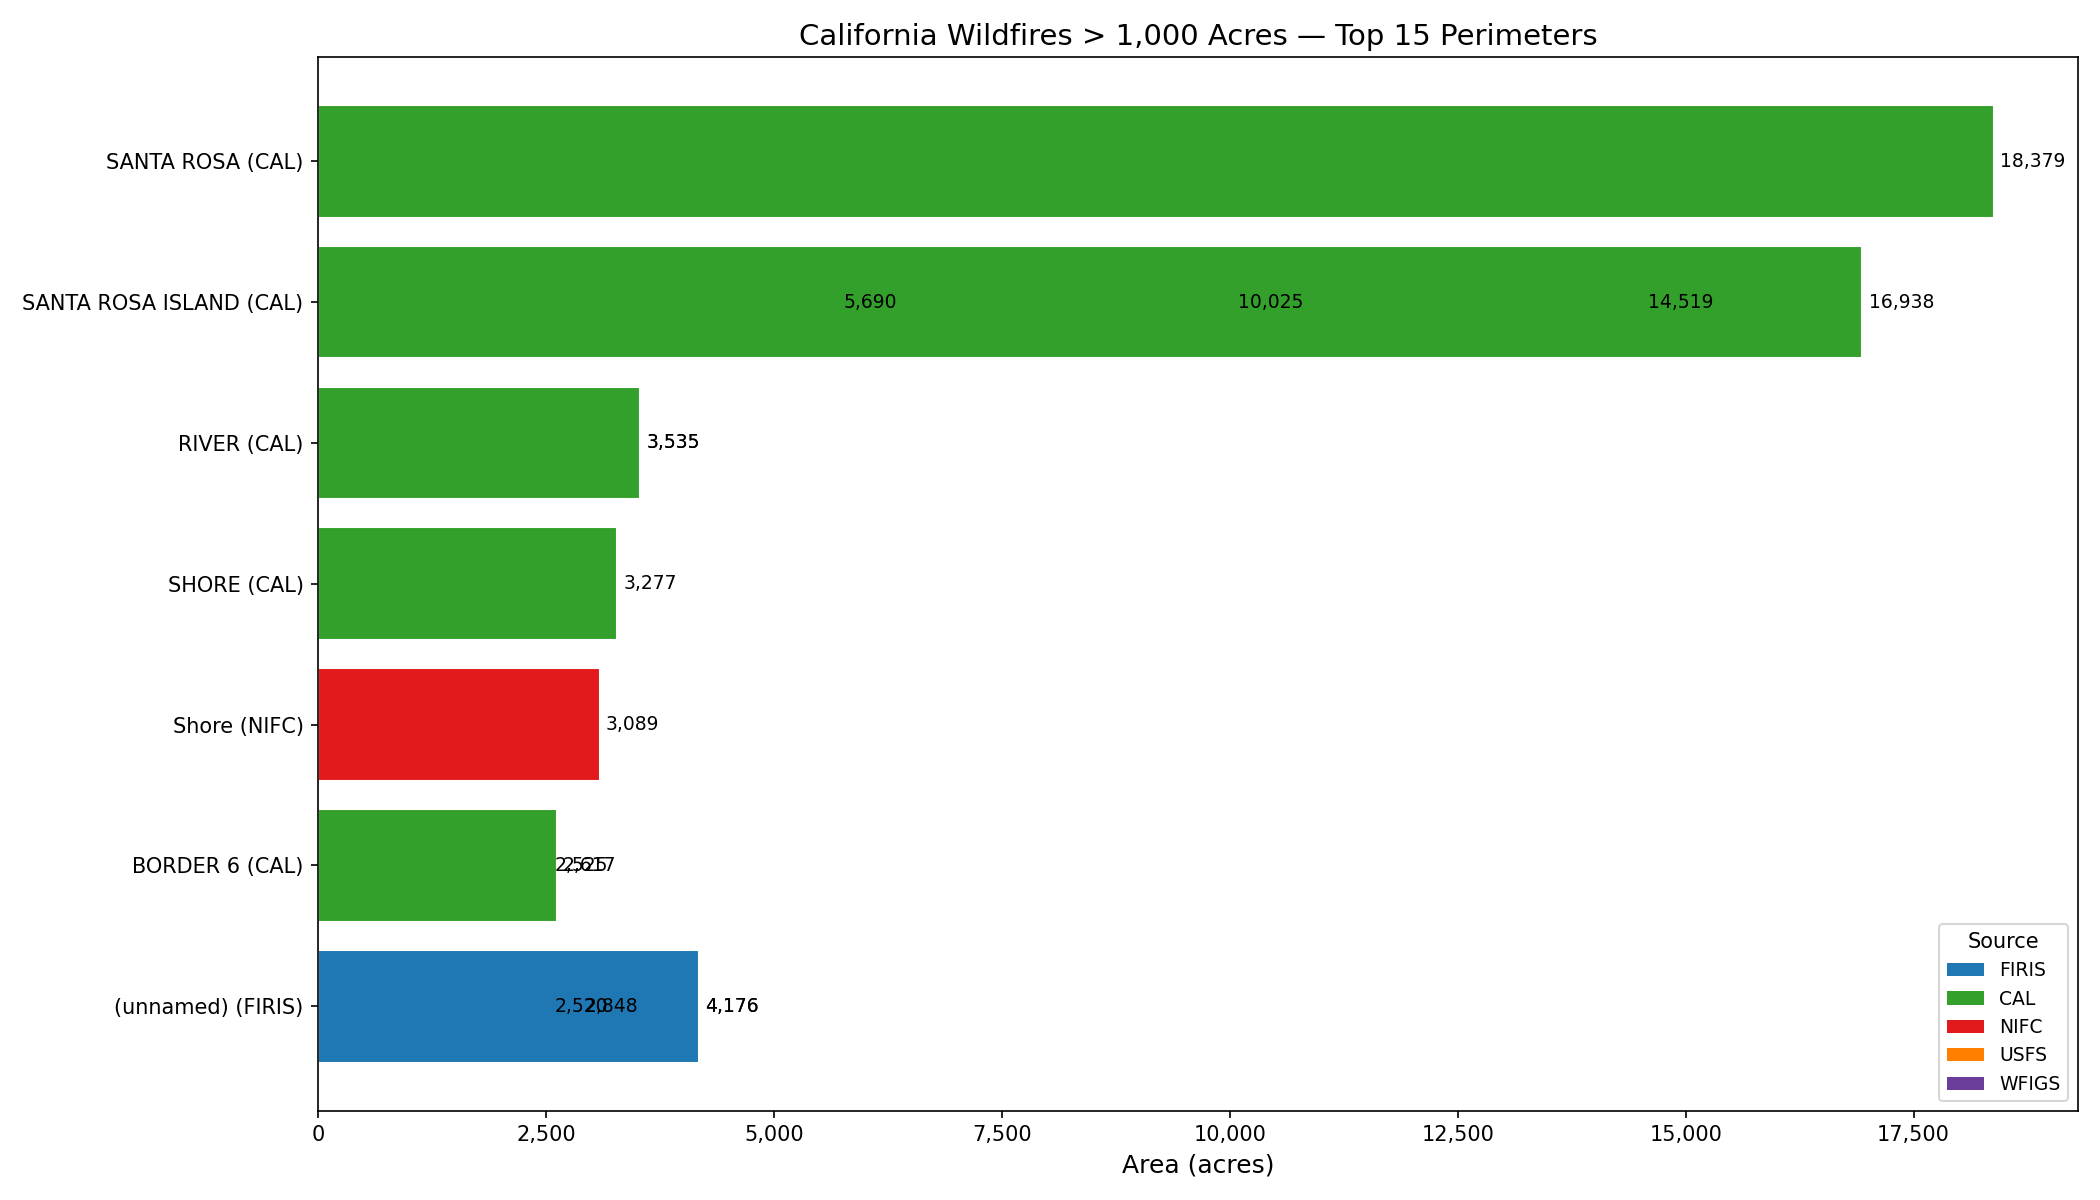

## Summary

| Metric | Value |
|---|---|
| **Total perimeters > 1,000 acres** | 38 |
| **Largest fire** | SANTA ROSA — 18,378.7 acres |
| **Smallest qualifying** | (unnamed FIRIS) — 1,098.2 acres |
| **All marked status** | Inactive (historical perimeters) |

## Breakdown by source agency

| Source | Perimeters |
|---|---|
| CAL FIRE INTEL FLIGHT DATA | 20 |
| FIRIS | 13 |
| NIFC | 2 |
| WFIGS | 2 |
| USFS | 1 |

## Top 10 perimeters by acreage

| Rank | Incident | Source | Acres |
|---|---|---|---|
| 1 | SANTA ROSA | CAL FIRE INTEL FLIGHT DATA | 18,378.7 |
| 2 | SANTA ROSA ISLAND | CAL FIRE INTEL FLIGHT DATA | 16,937.7 |
| 3 | SANTA ROSA ISLAND | CAL FIRE INTEL FLIGHT DATA | 14,519.3 |
| 4 | SANTA ROSA ISLAND | CAL FIRE INTEL FLIGHT DATA | 10,025.5 |
| 5 | SANTA ROSA ISLAND | CAL FIRE INTEL FLIGHT DATA | 5,690.4 |
| 6 | (unnamed) | FIRIS | 4,175.9 |
| 7 | (unnamed) | FIRIS | 4,175.9 |
| 8 | RIVER | CAL FIRE INTEL FLIGHT DATA | 3,534.9 |
| 9 | RIVER | CAL FIRE INTEL FLIGHT DATA | 3,534.9 |
| 10 | SHORE | CAL FIRE INTEL FLIGHT DATA | 3,277.0 |

## Named fires > 1,000 acres

The distinct named incidents (collapsing duplicate perimeter snapshots): **SANTA ROSA / SANTA ROSA ISLAND** (largest, ~18.4k acres), **RIVER** (~3,535), **SHORE** (~3,277 / 3,089), **BORDER 6** (~2,617), **SANDY** (~2,183), **CANYON** (~2,000), **WALTZ** (~1,644), **BAIN** (~1,497), and **MATEO** (~1,292). Thirteen FIRIS-sourced perimeters have blank incident names.

**Notes:** Many incidents appear multiple times because agencies submit repeated perimeter snapshots as a fire evolves (e.g., SANTA ROSA ISLAND has 5 perimeters of decreasing size, suggesting progressive mapping or burn-down). All 38 perimeters are marked `Inactive` — this layer retains historical perimeters rather than only live incidents.

In [5]:
%%ask
Find all California wildfires > 1000 acres

In [6]:
%%skill
https://github.com/klinucsd/sage_skills/tree/main/society/public-schools

I'll read the relevant skills to understand their APIs, then combine the two datasets.

Now I understand both skill APIs. Let me write a script to find schools within 1 mile of large fire perimeters.

Running the script to find schools near large fires.

Found 17 schools within 1 mile of large fires. Let me verify the output files are in place.

**17 public schools** sit within one mile of a California wildfire perimeter larger than 1,000 acres.


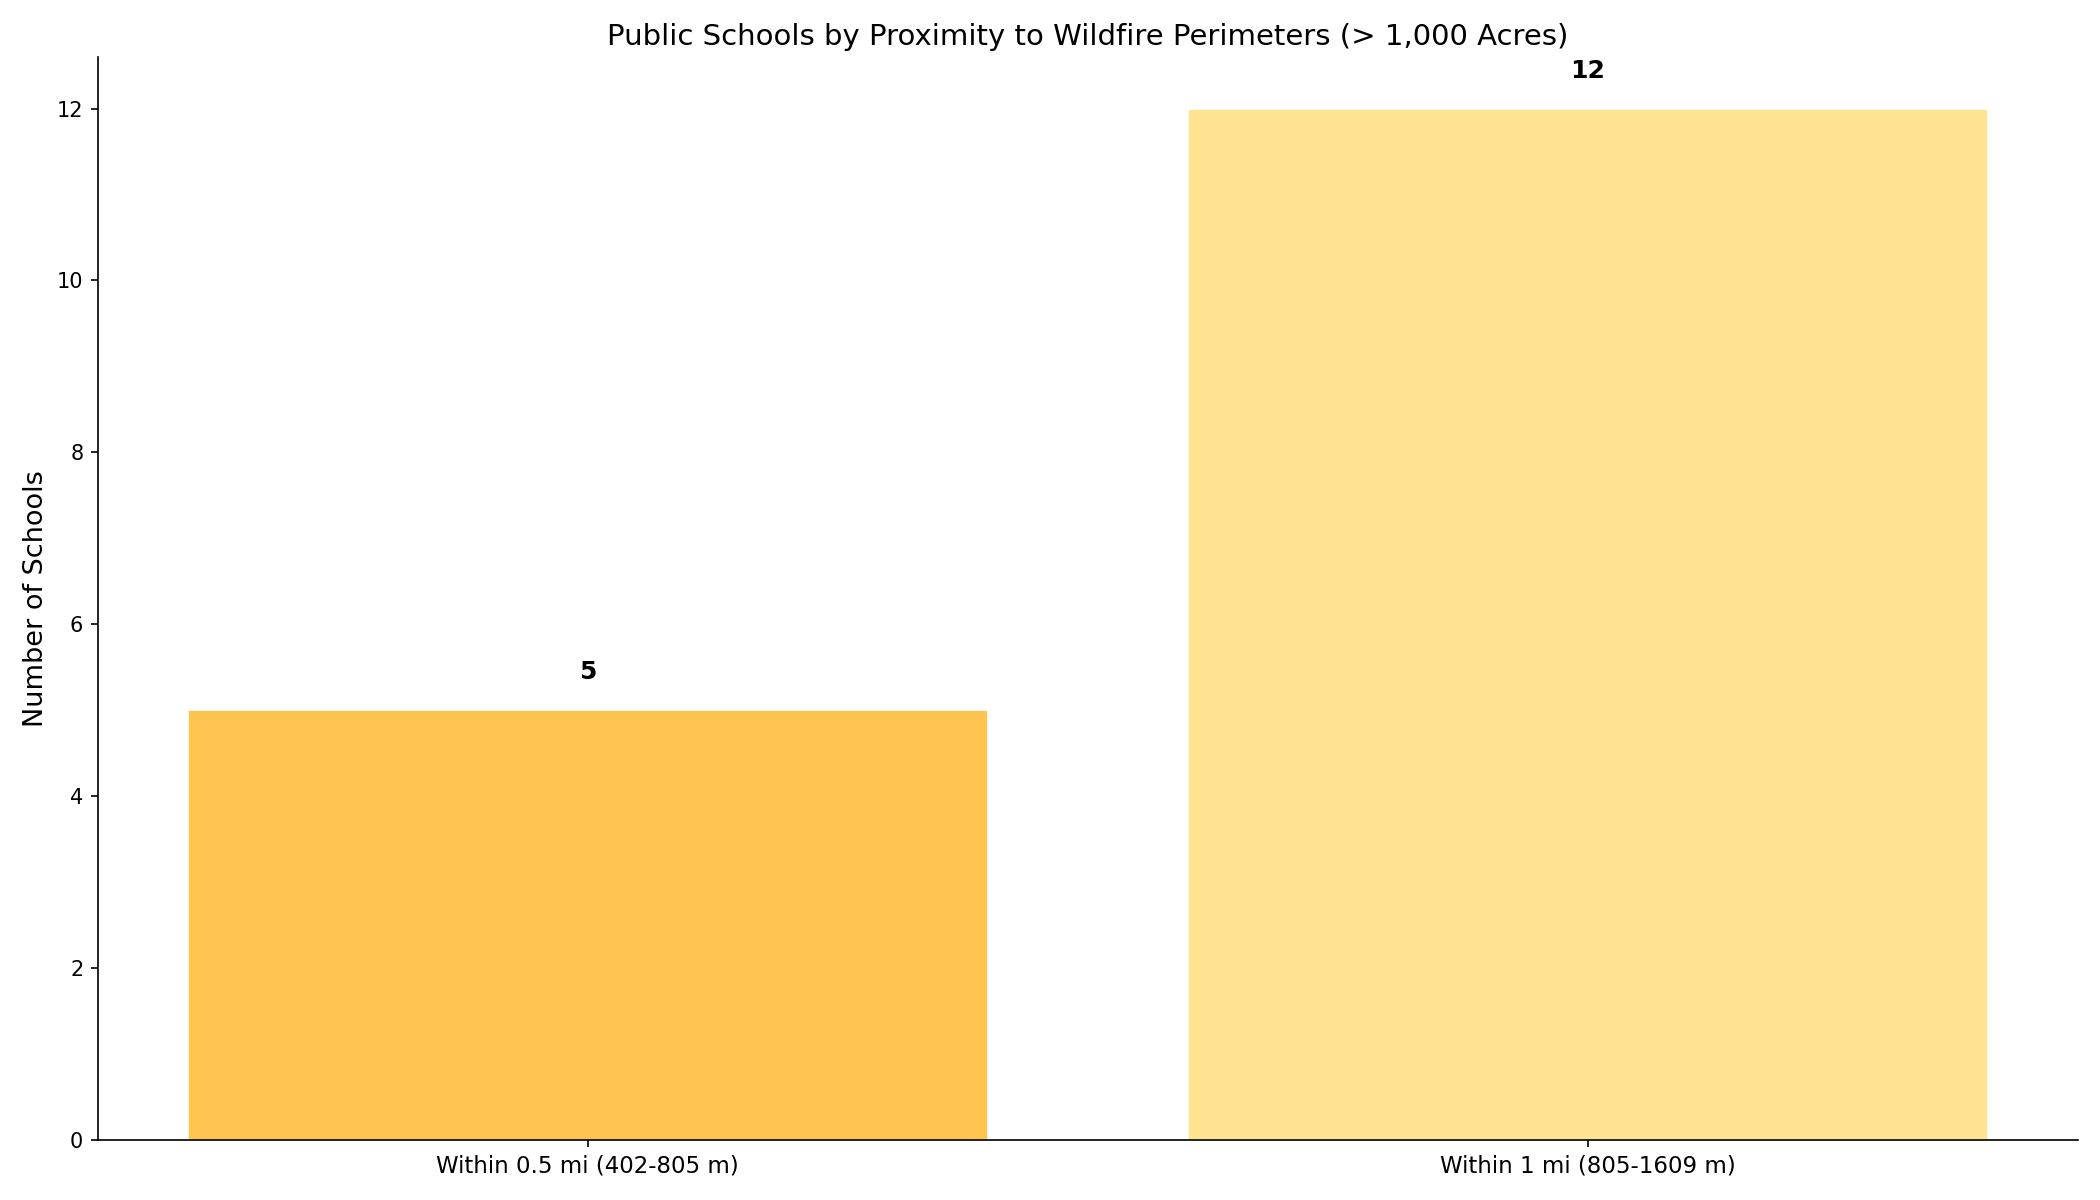


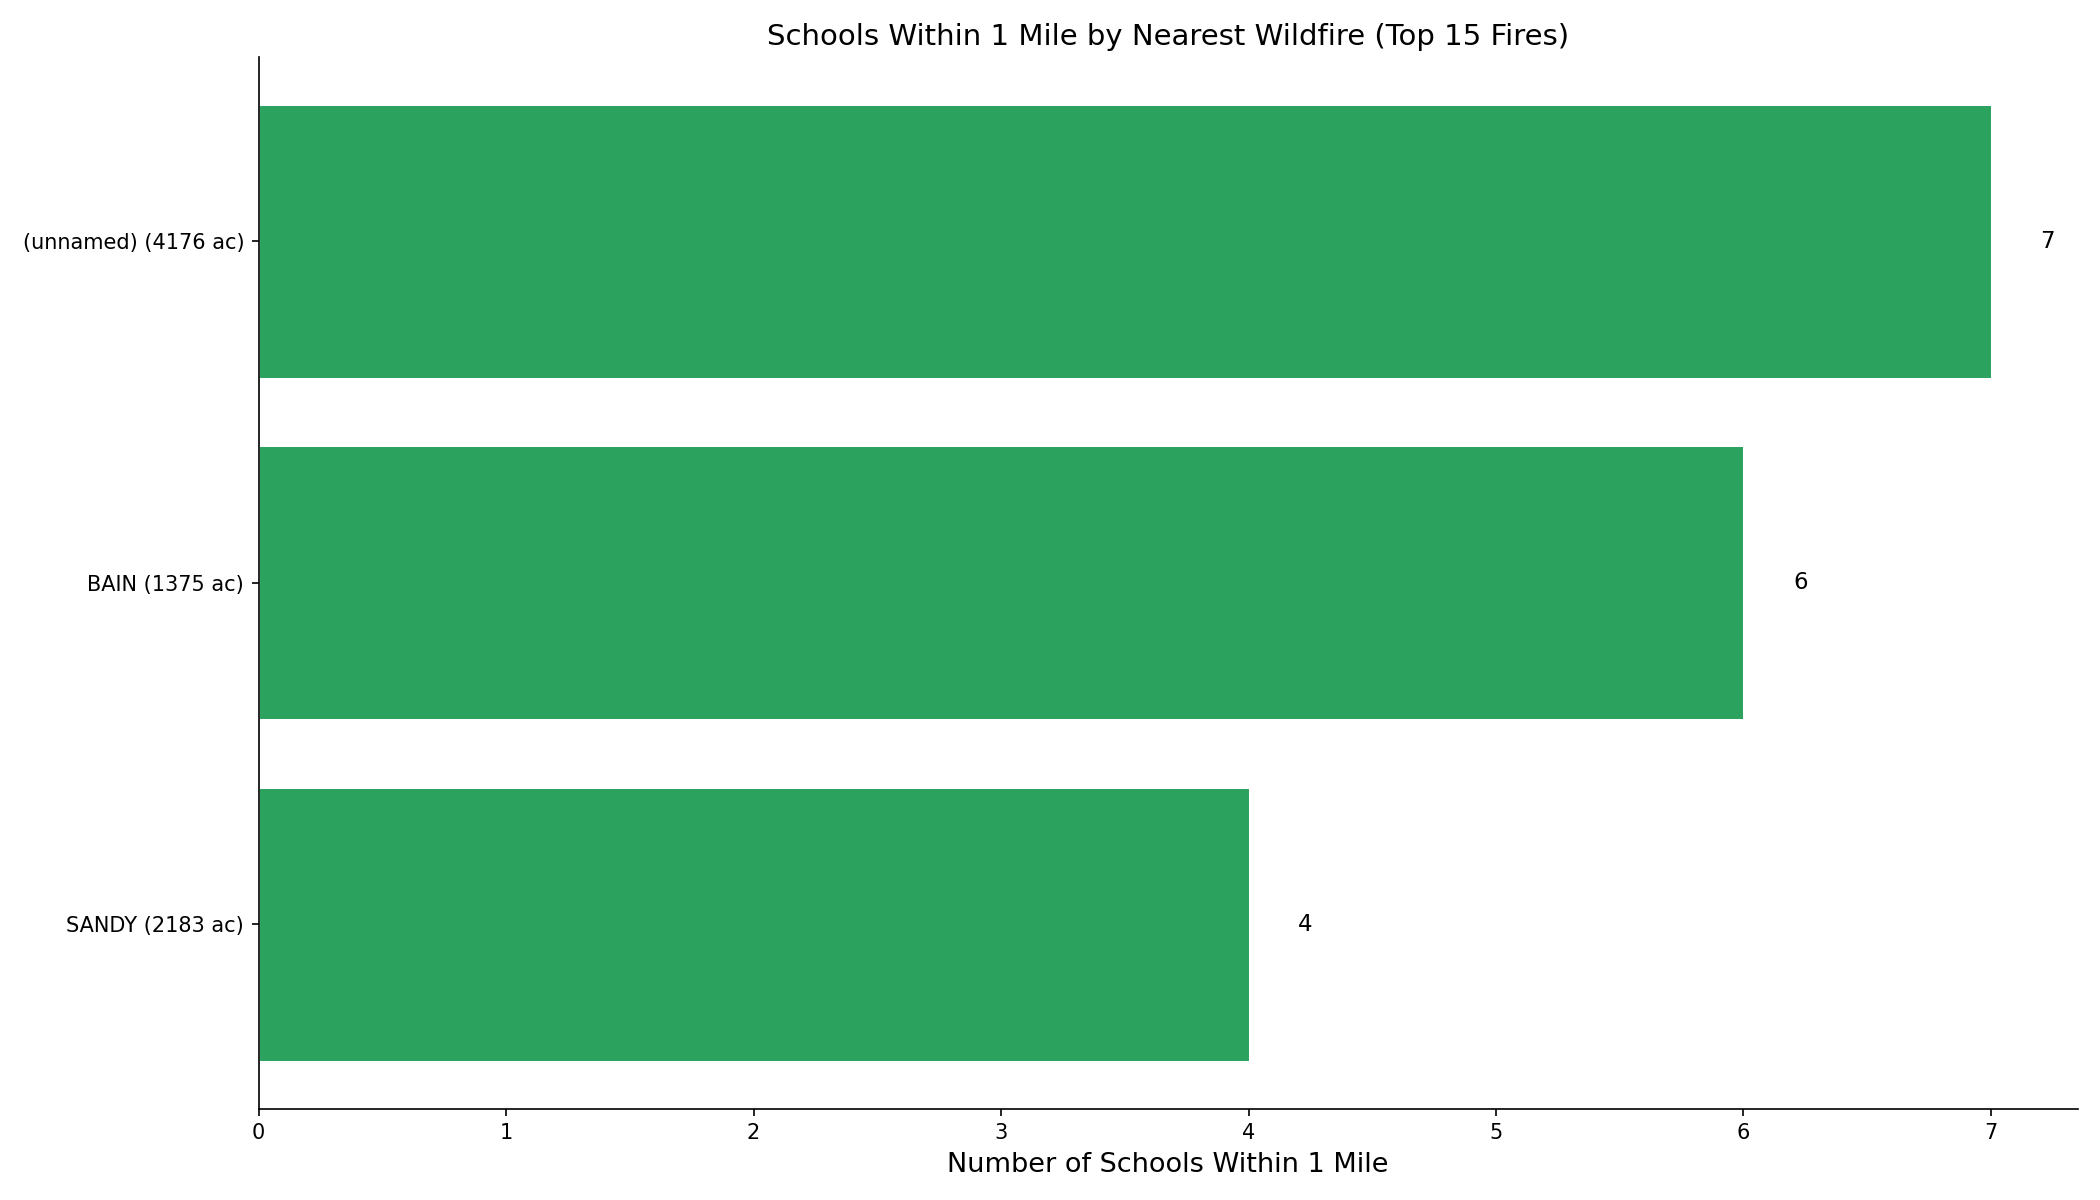

## Summary

| Metric | Value |
|---|---|
| **Schools within 1 mile** | 17 |
| **Within 0.5 mi (402–805 m)** | 5 |
| **Within 1 mi (805–1609 m)** | 12 |
| **Inside a perimeter** | 0 |
| **Fires affecting ≥1 school** | 3 of 38 large fires |

## Schools by proximity band

| Proximity | Schools |
|---|---|
| Within 0.5 mi (402-805 m) | 5 |
| Within 1 mi (805-1609 m) | 12 |

No school falls directly inside a mapped perimeter, but **5 schools are within a half-mile** of a >1,000-acre fire boundary.

## Schools by nearest fire

| Fire | Source | Acres | Schools within 1 mi |
|---|---|---|---|
| (unnamed) | FIRIS | 4,176 | 7 |
| BAIN | FIRIS | 1,375 | 6 |
| SANDY | CAL FIRE INTEL FLIGHT DATA | 2,183 | 4 |

Only **3 of 38** large fires have any school within a mile — the rest burn in wildland areas away from populated centers. The affected fires cluster around **Moreno Valley / Riverside** (Inland Empire) and **Simi Valley** (Ventura County).

## Closest 10 schools to fire perimeters

| School | Level | City | Nearest fire | Distance (mi) | Enrollment |
|---|---|---|---|---|---|
| RANCHO VERDE HIGH | HIGH | Moreno Valley | (unnamed) | 0.290 | 2,371 |
| CRESTVIEW ELEMENTARY | ELEMENTARY | Simi Valley | SANDY | 0.303 | 288 |
| RIDGE CREST ELEMENTARY | ELEMENTARY | Moreno Valley | (unnamed) | 0.375 | 592 |
| HILLSIDE MIDDLE | MIDDLE | Simi Valley | SANDY | 0.428 | 935 |
| MOUNTAIN VIEW ELEMENTARY | ELEMENTARY | Simi Valley | SANDY | 0.497 | 355 |
| LOMA VISTA MIDDLE | MIDDLE | Riverside | BAIN | 0.527 | 1,051 |
| ROSEMARY KENNEDY ELEMENTARY | ELEMENTARY | Riverside | BAIN | 0.534 | 461 |
| HOLLOW HILLS ELEMENTARY | ELEMENTARY | Simi Valley | SANDY | 0.540 | 688 |
| INDIAN HILLS ELEMENTARY | ELEMENTARY | Jurupa Valley | BAIN | 0.541 | 580 |
| LANDMARK MIDDLE | MIDDLE | Moreno Valley | (unnamed) | 0.552 | 1,217 |

## Schools by level

| Level | Schools |
|---|---|
| Elementary | 10 |
| Middle | 4 |
| High | 2 |
| Not reported | 1 |

**Method:** Buffered each large fire perimeter by 1 mile (in EPSG:3310 California Albers), unioned the buffers, fetched all California public schools in the buffer envelope (5,922 candidates), and kept only schools whose point falls within the unioned buffer. For each surviving school, `sjoin_nearest` identified the closest perimeter and exact distance. Distances are edge-to-edge (perimeter boundary to school point), not centroid-to-centroid.

In [7]:
%%ask
Show public schools within one mile from a wildfire larger than 1,000 acres